# 02 - Data Cleaning

**Customer Financial Behavior Analysis for Banking Business Intelligence**


In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

df = pd.read_csv("bank_transactions_data_edited - new data(1).csv")
df.head()


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [ ]:
# Cek Missing Value
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage (%)": round(df.isnull().mean()*100,2)
})

missing[missing["Missing"]>0].sort_values("Percentage (%)",ascending=False)


,Missing,Percentage (%)
Location,30,1.18
DeviceID,30,1.18
TransactionType,30,1.18
TransactionID,29,1.14
PreviousTransactionDate,28,1.10
Channel,27,1.06
AccountBalance,27,1.06
TransactionAmount,26,1.02
TransactionDuration,26,1.02
TransactionDate,24,0.95


In [ ]:
# Menangani Missing Value
# Numerik -> Median
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Kategorikal -> Modus
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()


,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [ ]:
# Menghapus Data Duplikat
print("Duplicate sebelum:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate sesudah:", df.duplicated().sum())


Duplicate sebelum: 22
Duplicate sesudah: 0


In [ ]:
# Konversi Kolom Tanggal
date_cols = ["TransactionDate","PreviousTransactionDate"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].dtypes


,0
TransactionDate,datetime64[ns]
PreviousTransactionDate,datetime64[ns]


In [ ]:
# Validasi Nilai Tidak Wajar

df = df[df["TransactionAmount"] >= 0]
df = df[df["AccountBalance"] >= 0]
df = df[(df["CustomerAge"] >= 17) & (df["CustomerAge"] <= 100)]
df = df[df["LoginAttempts"] >= 0]
df = df[df["TransactionDuration"] >= 0]

print(df.shape)


(2515, 16)


In [ ]:
# Outlier Analysis Menggunakan IQR

numeric_cols = ["TransactionAmount","AccountBalance","CustomerAge","TransactionDuration"]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outlier)} outliers")


TransactionAmount: 113 outliers
AccountBalance: 0 outliers
CustomerAge: 0 outliers
TransactionDuration: 0 outliers


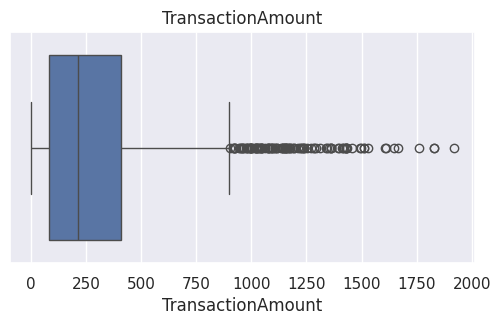

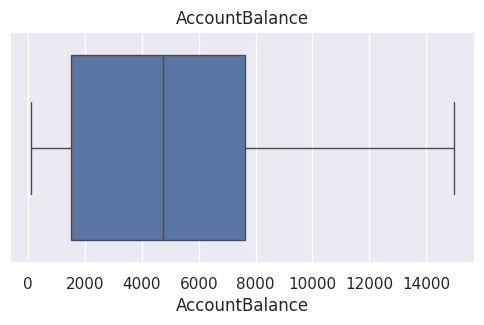

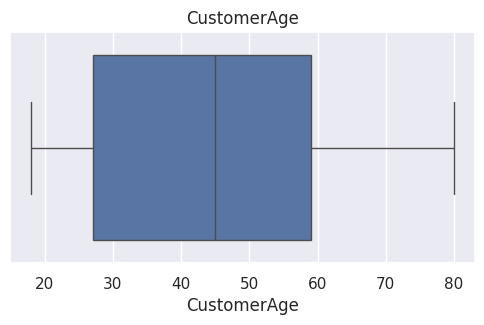

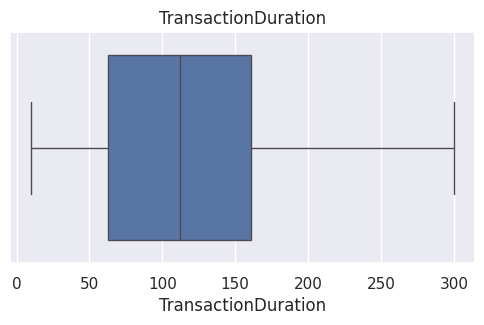

In [ ]:
# Boxplot Outlier

for col in ["TransactionAmount","AccountBalance","CustomerAge","TransactionDuration"]:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [ ]:
# Menghapus Outlier dengan IQR

clean_df = df.copy()

for col in ["TransactionAmount","AccountBalance","CustomerAge","TransactionDuration"]:

    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    clean_df = clean_df[(clean_df[col]>=lower) & (clean_df[col]<=upper)]

print("Shape sebelum:", df.shape)
print("Shape sesudah:", clean_df.shape)


Shape sebelum: (2515, 16)
Shape sesudah: (2402, 16)


In [ ]:
# Simpan Dataset Bersih

clean_df.to_csv("bank_transactions_clean.csv", index=False)

print("Dataset berhasil disimpan.")
clean_df.head()


Dataset berhasil disimpan.


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


## Kesimpulan

Tahap data cleaning meliputi:

- Menangani missing value
- Menghapus data duplikat
- Mengonversi tipe data tanggal
- Memvalidasi nilai yang tidak masuk akal
- Analisis outlier menggunakan metode IQR
- Menyimpan dataset bersih untuk tahap EDA
